In [1]:
import pickle 
from matplotlib import pyplot as plt
import casadi as cs
import numpy as np
from NMM.solver import Continuation_Solver
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib import animation
from matplotlib.gridspec import GridSpec


np.set_printoptions(precision=6, suppress=True)
bgColor = '#24273a'
mainColor = '#cad3f5'

In [2]:
def prettify(ax,xlabel='',ylabel='',title='',fgColor='#cad3f5',bgColor='#24273a',fontsize=14):
    ax.set_xlabel(xlabel,fontsize=fontsize,color=fgColor)
    ax.set_ylabel(ylabel,fontsize=fontsize,color=fgColor)
    ax.set_title(title,fontsize=fontsize,color=fgColor)
    ax.spines['bottom'].set_color(fgColor)
    ax.spines['top'].set_color(fgColor)
    ax.spines['left'].set_color(fgColor)
    ax.spines['right'].set_color(fgColor)
    ax.xaxis.label.set_color(fgColor)
    ax.yaxis.label.set_color(fgColor)
    ax.tick_params(axis='x', colors=fgColor)
    ax.tick_params(axis='y', colors=fgColor)
    ax.set_facecolor(bgColor)

In [3]:
def prettify3D(ax,xlabel='',ylabel='',zlabel='',title='',fgColor='#cad3f5',bgColor='#24273a',fontsize=18):
    ax.set_xlabel(xlabel,fontsize=fontsize,color=fgColor)
    ax.set_ylabel(ylabel,fontsize=fontsize,color=fgColor)
    ax.set_zlabel(zlabel,fontsize=fontsize,color=fgColor)
    ax.set_title(title,fontsize=fontsize,color=fgColor)
    ax.xaxis.line.set_color(fgColor)
    ax.yaxis.line.set_color(fgColor)
    ax.zaxis.line.set_color(fgColor)
    ax.tick_params(axis='x', colors=fgColor)
    ax.tick_params(axis='y', colors=fgColor)
    ax.tick_params(axis='z', colors=fgColor)
    ax.xaxis.label.set_color(fgColor)
    ax.yaxis.label.set_color(fgColor)
    ax.zaxis.label.set_color(fgColor)
    ax.set_facecolor(bgColor)
    frame = ax.legend(fontsize=fontsize,labelcolor=fgColor).get_frame()
    frame.set_facecolor(bgColor)
    frame.set_edgecolor(fgColor)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(fgColor)
    ax.yaxis.pane.set_edgecolor(fgColor)
    ax.zaxis.pane.set_edgecolor(fgColor)

In [4]:
def spring(start, end, nodes, width):
    nodes = max(int(nodes), 1)

    start, end = np.array(start).reshape((2,)), np.array(end).reshape((2,))

    if (start == end).all():
        return start[0], start[1]

    length = np.linalg.norm(np.subtract(end, start))

    u_t = np.subtract(end, start) / length
    u_n = np.array([[0, -1], [1, 0]]).dot(u_t)

    spring_coords = np.zeros((2, nodes + 2))
    spring_coords[:,0], spring_coords[:,-1] = start, end

    normal_dist = np.sqrt(max(0, width**2 - (length**2 / nodes**2))) / 2

    for i in range(1, nodes + 1):
        spring_coords[:,i] = (
            start
            + ((length * (2 * i - 1) * u_t) / (2 * nodes))
            + (normal_dist * (-1)**i * u_n))

    return spring_coords[0,:], spring_coords[1,:]

In [5]:
def traj(solver,u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = solver.traj_f_list(x0, dt[0], xi)
    traj2 = solver.stance_to_flight(
        solver.traj_s_list(solver.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = solver.traj_f_list(traj2[:, -1], dt[2], xi)
    traj1[0, :] += traj2[0, 0] - traj1[0, -1]
    traj3[0, :] += traj2[0, -1] - traj3[0, 0]
    traj = cs.horzcat(traj1, traj2, traj3, traj1[:,0])
    return np.array(traj)

In [6]:
def get_surface(N,data,solver):
    surface = np.zeros((N,6,2*solver.N_F + solver.N_S + 1))
    fcolor = np.zeros((N,2*solver.N_F + solver.N_S + 1))
    for i in range(N):
        surface[i,:,:] = traj(solver,data[int(i*2000/N)])
        fcolor[i,:] = data[int(i*2000/N)][-1]
    return surface,fcolor

In [7]:
solver = Continuation_Solver(40,cs.sqrt(10),1000,0.01,True)

In [8]:
data_locomotion = pickle.load(open('data/data_locomotion.pkl', 'rb'))
data_switch = pickle.load(open('data/data_switch.pkl', 'rb'))
data_test = pickle.load(open('data/data_test.pkl', 'rb'))


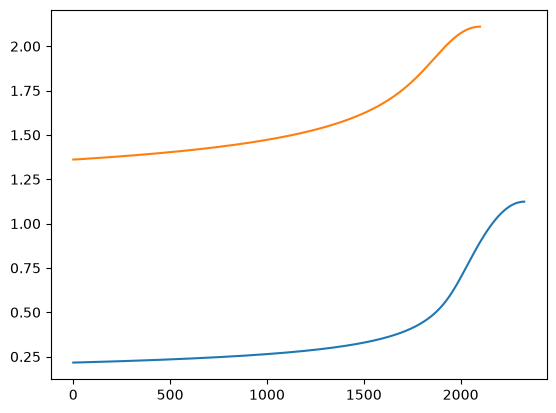

In [9]:
def reorder(branch):
    traj = np.array(branch)
    idx = 0
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 0.02:
            idx = i+1
    fixed_traj = np.vstack([np.flip(traj[:idx,:],axis=0),traj[idx:,:]])
    if traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        fixed_traj[:,[0,2,3,5]] = - fixed_traj[:,[0,2,3,5]]
    return fixed_traj

def separate(traj):
    idx = 0
    for i in range(100,traj.shape[0] -101):
        de1 = traj[i,-1] - traj[i-1,-1]
        de2 = traj[i+1,-1] - traj[i,-1]
        if de1*de2 < 0:
            idx = i + 1
    return traj[:idx,:],traj[idx:,:]

L1 = reorder(data_locomotion[2])
L11,L12 = separate(L1)
L2 = reorder(data_locomotion[4])
L21,L22 = separate(L2)
L3 = reorder(data_locomotion[6])
L31,L32 = separate(L3)
L4 = reorder(data_locomotion[8])
L41,L42 = separate(L4)

S1 = reorder(data_switch[2])
S2 = reorder(data_switch[4])


plt.plot(S1[:,1])
plt.plot(S2[:,1])
# plt.plot(L2[:,1])
# plt.plot(L22[:,1])

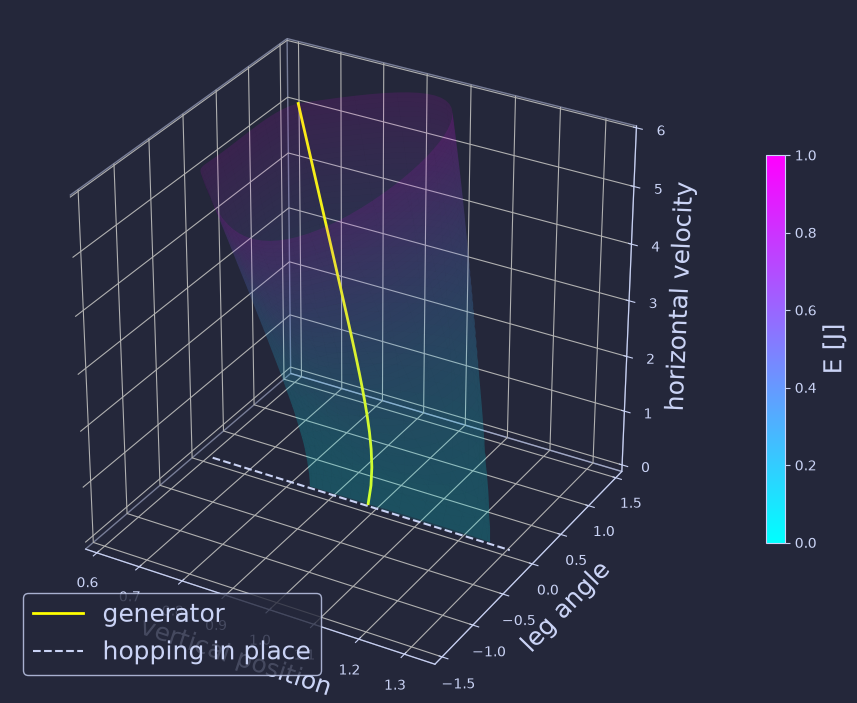

In [10]:
from matplotlib import colorbar,colors,colorizer

idx = [1,2,3]
Nframes = 30

surface_locomotion,faces = get_surface(50,data_locomotion[4],solver)
norm = colors.Normalize(vmin=faces.min(), vmax=faces.max())
fcolor = cm.cool(norm(faces))[:-1, :-1]
fig_surface = plt.figure(figsize=(10,10),facecolor=bgColor)
ax = fig_surface.add_subplot(1,1,1,projection='3d')
ax.plot_surface(surface_locomotion[:,idx[0]], surface_locomotion[:,idx[1]], surface_locomotion[:,idx[2]],facecolors=fcolor,shade=False, edgecolor='none', alpha=0.1)
ax.plot(surface_locomotion[:,idx[0],solver.N_F],surface_locomotion[:,idx[1],solver.N_F],surface_locomotion[:,idx[2],solver.N_F],linewidth = 2, color='#ffff00', label='generator')
x_min,x_max = ax.get_xlim()


col = colorizer.Colorizer(norm=colors.Normalize(0,1), cmap='cool')

cbar = fig_surface.colorbar(colorizer.ColorizingArtist(col),
             ax=ax, orientation='vertical', fraction=0.025,pad=0.1, aspect=20)

cbar.outline.set_edgecolor(mainColor)
cbar.ax.tick_params(axis='y', colors=mainColor)
cbar.set_label('E [J]', color=mainColor,fontsize=18)

ax.plot([x_min,x_max],[0,0],[0,0],'--',color=mainColor,label='hopping in place')
ax.legend()
prettify3D(ax,xlabel='vertical position', ylabel='leg angle', zlabel='horizontal velocity')
ax.set_box_aspect((4,4,4))
ax.grid('off')
plt.show()

def animate(i):
    # ax.view_init(elev=35. - 20/Nframes * i, azim=45+(360/(3*Nframes)) * i)
    ax.view_init(elev=20, azim=45+(360/(Nframes)) * i)


ani = animation.FuncAnimation(
    fig_surface, animate, Nframes, interval=1, blit=True)

writervideo = animation.FFMpegWriter(fps=30) 
ani.save('output/test.mp4', writer=writervideo, savefig_kwargs=dict(facecolor=bgColor)) 

In [11]:
def plot_traj(ax,traj,c,lw=0.5):
    ax.plot(traj[1,:],traj[2,:],traj[3,:], linewidth=lw,color=c)

def plot_generator(ax,branch,c,lw,STEP_SIZE,IDX,linestyle='-',d=1,plot_TP=False):
    traj = np.array(branch)
    idx = 0
    idx_TP = []
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 2*STEP_SIZE:
            idx = i
        if plot_TP and i>20 and i<traj.shape[0]-20 and np.linalg.det(solver.compute_Jz(traj[i+1,:10],traj[i+1,10])) * np.linalg.det(solver.compute_Jz(traj[i,:10],traj[i,10]))<0:
            idx_TP.append(i)

    if traj[-1,3] > 1e-2 or traj[0,3] > 1e-2:
        ax.plot(traj[:idx+1,IDX[0]],d*traj[:idx+1,IDX[1]],d*traj[:idx+1,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],d*traj[idx+1:,IDX[1]],d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx,IDX[0]],d*traj[idx,IDX[1]],d*traj[idx,IDX[2]],marker='o' if np.abs(traj[idx,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        ax.plot(traj[-1,IDX[0]],d*traj[-1,IDX[1]],d*traj[-1,IDX[2]],marker='o' if np.abs(traj[-1,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        for i in idx_TP:
            ax.plot(traj[i,IDX[0]],d*traj[i,IDX[1]],d*traj[i,IDX[2]],marker='d' ,ms=10,color='#fe7f2d')

    elif traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        ax.plot(traj[:idx,IDX[0]],-d*traj[:idx,IDX[1]],-d*traj[:idx,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx+1:,IDX[0]],-d*traj[idx+1:,IDX[1]],-d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(traj[idx,IDX[0]],-d*traj[idx,IDX[1]],-d*traj[idx,IDX[2]],marker='o' if np.abs(traj[idx,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        ax.plot(traj[-1,IDX[0]],-d*traj[-1,IDX[1]],-d*traj[-1,IDX[2]],marker='o' if np.abs(traj[-1,3])<1e-2 else 'x',ms=10,color='#fe7f2d')
        for i in idx_TP:
            ax.plot(traj[i,IDX[0]],-d*traj[i,IDX[1]],-d*traj[i,IDX[2]],marker='d' ,ms=10,color='#fe7f2d')



In [40]:

Elist = np.linspace(0,Emax,Nframes)
ylist = np.linspace(1,2.6,1000)
ydata = ylist[np.argwhere(ylist<=3)]
(ydata.reshape((-1,)),np.zeros((ydata.shape[0],)),np.zeros((ydata.shape[0],)))

(array([1.      , 1.001602, 1.003203, 1.004805, 1.006406, 1.008008,
        1.00961 , 1.011211, 1.012813, 1.014414, 1.016016, 1.017618,
        1.019219, 1.020821, 1.022422, 1.024024, 1.025626, 1.027227,
        1.028829, 1.03043 , 1.032032, 1.033634, 1.035235, 1.036837,
        1.038438, 1.04004 , 1.041642, 1.043243, 1.044845, 1.046446,
        1.048048, 1.04965 , 1.051251, 1.052853, 1.054454, 1.056056,
        1.057658, 1.059259, 1.060861, 1.062462, 1.064064, 1.065666,
        1.067267, 1.068869, 1.07047 , 1.072072, 1.073674, 1.075275,
        1.076877, 1.078478, 1.08008 , 1.081682, 1.083283, 1.084885,
        1.086486, 1.088088, 1.08969 , 1.091291, 1.092893, 1.094494,
        1.096096, 1.097698, 1.099299, 1.100901, 1.102503, 1.104104,
        1.105706, 1.107307, 1.108909, 1.110511, 1.112112, 1.113714,
        1.115315, 1.116917, 1.118519, 1.12012 , 1.121722, 1.123323,
        1.124925, 1.126527, 1.128128, 1.12973 , 1.131331, 1.132933,
        1.134535, 1.136136, 1.137738, 1.139339, 

/tmp/ipykernel_33962/3140392371.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  frame = ax.legend(fontsize=fontsize,labelcolor=fgColor).get_frame()


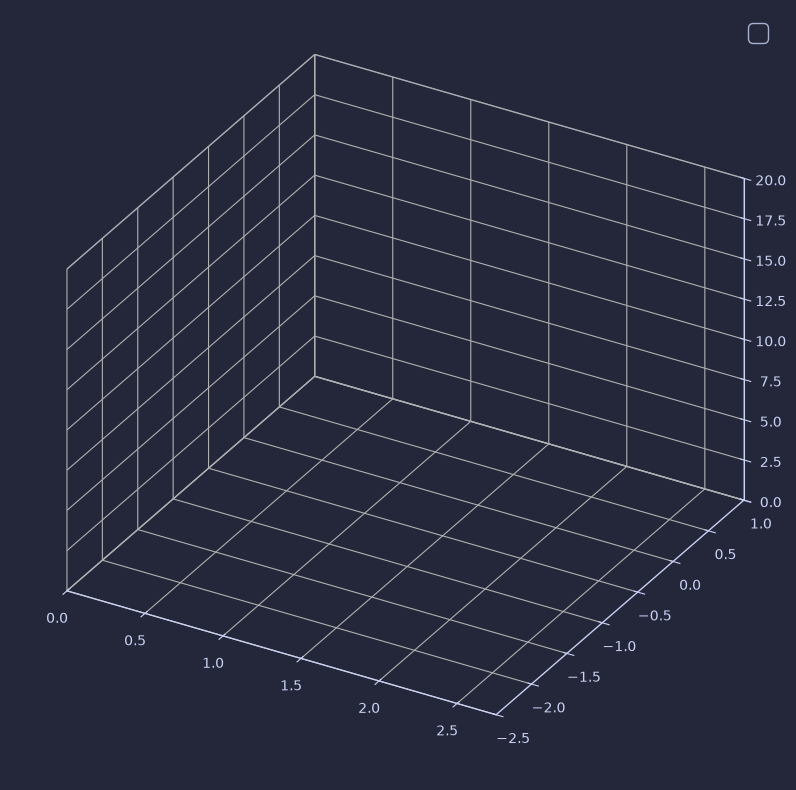

In [49]:
Emax = max(L1[:,-1])
fig_generator = plt.figure(figsize=(10,10),facecolor=bgColor)
Nframes = 300
Elist = np.geomspace(1,Emax,Nframes)
ylist = np.linspace(1,2.6,1000)
ax = fig_generator.add_subplot(1,1,1,projection='3d')
ax.set_proj_type('ortho')


def animate(i):
    # ax.view_init(elev=35. - 20/Nframes * i, azim=45-(360/(3*Nframes)) * i)
    # ax.view_init(elev=20, azim=45+(360/(Nframes)) * i)
    Elim = Elist[i]
    plot_L11.set_data_3d(
        L11[np.argwhere(L11[:,-1]<=Elim).reshape((-1,)),1],
        L11[np.argwhere(L11[:,-1]<=Elim).reshape((-1,)),2],
        L11[np.argwhere(L11[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L22.set_data_3d(
        L22[np.argwhere(L22[:,-1]<=Elim).reshape((-1,)),1],
        L22[np.argwhere(L22[:,-1]<=Elim).reshape((-1,)),2],
        L22[np.argwhere(L22[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L31.set_data_3d(
        L31[np.argwhere(L31[:,-1]<=Elim).reshape((-1,)),1],
        L31[np.argwhere(L31[:,-1]<=Elim).reshape((-1,)),2],
        L31[np.argwhere(L31[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L42.set_data_3d(
        L42[np.argwhere(L42[:,-1]<=Elim).reshape((-1,)),1],
        L42[np.argwhere(L42[:,-1]<=Elim).reshape((-1,)),2],
        L42[np.argwhere(L42[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L12.set_data_3d(
        L12[np.argwhere(L12[:,-1]<=Elim).reshape((-1,)),1],
        L12[np.argwhere(L12[:,-1]<=Elim).reshape((-1,)),2],
        L12[np.argwhere(L12[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L21.set_data_3d(
        L21[np.argwhere(L21[:,-1]<=Elim).reshape((-1,)),1],
        L21[np.argwhere(L21[:,-1]<=Elim).reshape((-1,)),2],
        L21[np.argwhere(L21[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L32.set_data_3d(
        L32[np.argwhere(L32[:,-1]<=Elim).reshape((-1,)),1],
        L32[np.argwhere(L32[:,-1]<=Elim).reshape((-1,)),2],
        L32[np.argwhere(L32[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_L41.set_data_3d(
        L41[np.argwhere(L41[:,-1]<=Elim).reshape((-1,)),1],
        L41[np.argwhere(L41[:,-1]<=Elim).reshape((-1,)),2],
        L41[np.argwhere(L41[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_S1.set_data_3d(
        S1[np.argwhere(S1[:,-1]<=Elim).reshape((-1,)),1],
        S1[np.argwhere(S1[:,-1]<=Elim).reshape((-1,)),2],
        S1[np.argwhere(S1[:,-1]<=Elim).reshape((-1,)),3]
    )
    plot_S2.set_data_3d(
        S2[np.argwhere(S2[:,-1]<=Elim).reshape((-1,)),1],
        S2[np.argwhere(S2[:,-1]<=Elim).reshape((-1,)),2],
        S2[np.argwhere(S2[:,-1]<=Elim).reshape((-1,)),3]
    )
    ydata = ylist[np.argwhere(ylist<=Elim)]
    plot_L0.set_data_3d(ydata.reshape((-1,)),np.zeros((ydata.shape[0],)),np.zeros((ydata.shape[0],)))
 

# for c,M in zip(['#8aadf4','#a6da95','#8aadf4','#a6da95'],[data_locomotion[i] for i in [2,4,6,8]]):
#     plot_generator(ax,M,c,2,0.01,idx,plot_TP=False)
# for M in [data_switch[i] for i in [2,4]]:
#     plot_generator(ax,M,'#ed8796',2,0.01,idx,linestyle='-.',plot_TP=False)
# x_min,x_max = ax.get_xlim()
# ax.plot([x_min,x_max],[0,0],[0,0],'--',zorder=0,color=mainColor)

ax.set_xlim(0,2.75)
ax.set_ylim([-2.5,1])
ax.set_zlim(0,20)

(plot_L0,) = ax.plot([],[],[],color='#cad3f5',linewidth=4,linestyle='--')
(plot_L11,) = ax.plot([],[],[],color='#8aadf4',linewidth=4)
(plot_L21,) = ax.plot([],[],[],color='#a6da95',linewidth=4)
(plot_L31,) = ax.plot([],[],[],color='#8aadf4',linewidth=4)
(plot_L41,) = ax.plot([],[],[],color='#a6da95',linewidth=4)
(plot_L12,) = ax.plot([],[],[],color='#8aadf4',linewidth=4)
(plot_L22,) = ax.plot([],[],[],color='#a6da95',linewidth=4)
(plot_L32,) = ax.plot([],[],[],color='#8aadf4',linewidth=4)
(plot_L42,) = ax.plot([],[],[],color='#a6da95',linewidth=4)
(plot_S1,) = ax.plot([],[],[],color='#ed8796',linewidth=4)
(plot_S2,) = ax.plot([],[],[],color='#ed8796',linewidth=4)
# plot_L12, = ax.plot([],[],[],color='#8bd5ca',linewidth=2)

prettify3D(ax)
plt.show()

ani = animation.FuncAnimation(
    fig_generator, animate, Nframes, interval=1, blit=True)

writervideo = animation.FFMpegWriter(fps=30) 
ani.save('output/generators.mp4', writer=writervideo, savefig_kwargs=dict(facecolor=bgColor)) 

In [ ]:


def interpolate_trajectory(traj,tf,fps):
    times = np.linspace(0,tf,traj.shape[1])
    N_frames = int(tf*fps)
    T = np.linspace(0,tf,N_frames)
    xh = np.zeros((traj.shape[0],N_frames))
    i_ = 0
    for i in range(N_frames):
        while T[i] > times[i_+1]:
            i_+=1
        alpha = (T[i] - times[i_])/(times[i_+1]-times[i_])
        xh[:,i] = (1-alpha) * traj[:,i_] + alpha * traj[:,i_+1] 
    return xh

def clean_step(u,fps):
    full_traj = traj(solver,u)[:,:-1]
    xf1 = interpolate_trajectory(full_traj[:,:solver.N_F-1],solver.N_F*u[6]/solver.W,fps)[:,:-1]
    xs = interpolate_trajectory(full_traj[:,solver.N_F:solver.N_F+solver.N_S-1],solver.N_S*u[7]/solver.W,fps)[:,:-1]
    xf2 = interpolate_trajectory(full_traj[:,solver.N_F+solver.N_S:],solver.N_F*u[8]/solver.W,fps)
    xh = np.hstack([xf1,xs,xf2])
    ah = xh[2,:]
    rh = np.hstack([np.ones(xf1.shape[1],),np.sqrt(xs[0,:]**2 + xs[1,:]**2),np.ones(xf2.shape[1],)])
    return xh,rh,ah

def key_frames(u,fps):
    full_traj = traj(solver,u)
    xf1 = interpolate_trajectory(full_traj[:,:solver.N_F-1],solver.N_F*u[6]/solver.W,fps)
    xs = interpolate_trajectory(full_traj[:,solver.N_F:solver.N_F+solver.N_S-1],solver.N_S*u[7]/solver.W,fps)
    xf2 = interpolate_trajectory(full_traj[:,solver.N_F+solver.N_S:],solver.N_F*u[8]/solver.W,fps)[:,:-1]
    x_frames = np.vstack([xf1[:,0],xf1[:,xf1.shape[1]//2],xs[:,0],xs[:,xs.shape[1]//2],xs[:,-1],xf2[:,xf2.shape[1]//2],xf2[:,-1]])
    r_frames = np.hstack([1,1,1,np.sqrt(xs[0,xs.shape[1]//2]**2 + xs[1,xs.shape[1]//2]**2),1,1,1])
    a_frames = x_frames[:,2]
    return x_frames.T,r_frames, a_frames


def clean_trajectory(u,fps):
    xh1,rh,ah = clean_step(u,fps)
    xh2 = xh1.copy()
    xh3 = xh2.copy()
    xh2[0,:] += xh1[0,-1] - xh2[0,0]
    xh3[0,:] += xh2[0,-1] - xh3[0,0]
    xh = np.hstack([xh1[:,:-1],xh2[:,:-1],xh3])
    rh = np.hstack([rh[:-1],rh[:-1],rh])
    ah = xh[2,:]
    return xh,rh,ah


In [11]:

# bgColor = '#24273a'
# mainColor = '#cad3f5'

# def frame(ax,i,xh,ah,rh):
#     radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
#     x0 = np.array([xh[0,i], xh[1,i]])
#     x1 = x0 - 0.25*radial
#     x2 = x0 - ( rh[i] - 0.25) * radial
#     x3 = x0 - rh[i] * radial
#     ax.plot([xh[0,i]], [xh[1,i]],c=mainColor,marker='o',ms=16)
#     X, Y = spring(
#         np.array([xh[0,i],xh[1,i]]) - 0.25 * radial,
#         np.array([xh[0,i],xh[1,i]]) - ( rh[i] - 0.25) * radial,
#         12,
#         0.18,
#     )
#     ax.plot(X, Y,c=mainColor)
#     ax.plot([x0[0],x1[0]],[x0[1],x1[1]],c=mainColor)
#     ax.plot([x2[0],x3[0]],[x2[1],x3[1]],c=mainColor)



# xh,rh,ah = key_frames(data_locomotion[4][1000],60)
# print(xh.shape)
# fig_kframes = plt.figure(figsize=(10,10),facecolor=bgColor)
# ax = fig_kframes.add_subplot(1,1,1)
# ax.set_facecolor(bgColor)
# ax.set(xticklabels=[], yticklabels=[])
# ax.set_axis_off()
# for i in range(xh.shape[1]):
#     frame(ax,i,xh,ah,rh)
# ax.set_aspect("equal")
# plt.show()


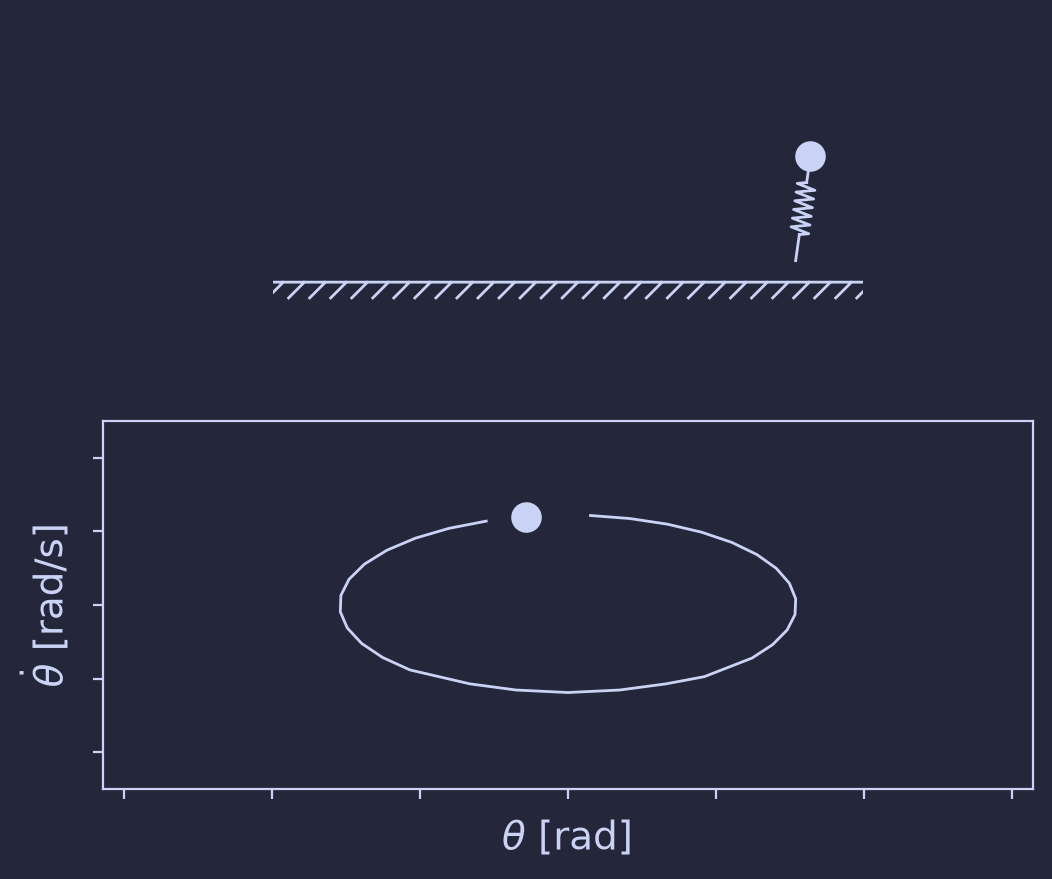

In [ ]:


xh, rh, ah = clean_trajectory(data_locomotion[4][500],60)
xh = xh[:,:xh.shape[1]//3]
T = (xh.shape[1] * 1/60) 

def animate(i):
    radial = np.array([-np.sin(ah[i]), np.cos(ah[i])])
    x0 = np.array([xh[0,i], xh[1,i]])
    x1 = x0 - 0.25*radial
    x2 = x0 - ( rh[i] - 0.25) * radial
    x3 = x0 - rh[i] * radial
    body.set_data([xh[0,i]], [xh[1,i]])
    X, Y = spring(
        np.array([xh[0,i],xh[1,i]]) - 0.25 * radial,
        np.array([xh[0,i],xh[1,i]]) - ( rh[i] - 0.25) * radial,
        12,
        0.18,
    )
    leg.set_data(X, Y)
    upper_leg.set_data([x0[0],x1[0]],[x0[1],x1[1]])
    lower_leg.set_data([x2[0],x3[0]],[x2[1],x3[1]])

    dot1.set_data([xh[2,i]],[xh[5,i]])
    plot1.set_data([xh[2,:i]],[xh[5,:i]])

    return body,leg,upper_leg,lower_leg,plot1,dot1


fig = plt.figure(figsize=(6, 5), dpi=200, facecolor=bgColor)
gs = GridSpec(4,4)
ax1 = fig.add_subplot(gs[:2,:])
ax2 = fig.add_subplot(gs[2:,:])

ax2.set(xticklabels=[], yticklabels=[])
prettify(ax2,xlabel=r'$\theta$ [rad]',ylabel=r'$\dot{\theta}$ [rad/s]')
ax2.set_xlim(-np.pi/2,np.pi/2)
ax2.set_ylim(-5,5)


ax1.set_xlim(np.min(xh[0,:])-0.5, np.max(xh[0,:])+0.5)
ax1.set_ylim(-1, 2.5)
ax1.set_aspect("equal")
ax1.set_facecolor(bgColor)
ax1.set(xticklabels=[], yticklabels=[])
ax1.set_axis_off()

(leg,) = ax1.plot([], [], lw=1.0, color=mainColor)
(upper_leg,) = ax1.plot([], [], lw=1.0, color=mainColor)
(lower_leg,) = ax1.plot([], [], lw=1.0, color=mainColor)
(body,) = ax1.plot([], [], "o", ms=10, lw=0, color=mainColor)

(plot1,) = ax2.plot([], [], lw=1.0, color=mainColor)
(dot1,) = ax2.plot([], [], "o", ms=10, lw=0, color=mainColor)

floor_coor = np.min(xh[0,:])-1
length = np.max(xh[0,:]) - np.min(xh[0,:]) + 2
for i in range(int(length/0.2)):
    ax1.plot([floor_coor+i*0.2,floor_coor+i*0.2 + 0.2,floor_coor+i*0.2 + 0.05],[0,0,-0.15], lw=1.0,color=mainColor)



ani = animation.FuncAnimation(fig, animate, range(0,xh.shape[1],1), blit=True,repeat=True)
writervideo = animation.FFMpegWriter(fps=20)
ani.save("output/periodic.mp4", writer=writervideo, savefig_kwargs=dict(facecolor=bgColor))

In [13]:
def plot_generator_alt(ax,branch,c,lw,STEP_SIZE,IDX,linestyle='-',d=1,plot_TP=False):
    traj = np.array(branch)
    idx = 0
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 2*STEP_SIZE:
            idx = i

    if traj[-1,3] > 1e-2 or traj[0,3] > 1e-2:
        ax.plot(np.log(traj[:idx+1,IDX[0]]),d*traj[:idx+1,IDX[1]],d*traj[:idx+1,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(np.log(traj[idx+1:,IDX[0]]),d*traj[idx+1:,IDX[1]],d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)

    elif traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        ax.plot(np.log(traj[:idx,IDX[0]]),-d*traj[:idx,IDX[1]],-d*traj[:idx,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)
        ax.plot(np.log(traj[idx+1:,IDX[0]]),-d*traj[idx+1:,IDX[1]],-d*traj[idx+1:,IDX[2]],linewidth = lw, color = c,linestyle=linestyle)

/tmp/ipykernel_70115/1689435179.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  frame = ax.legend(fontsize=fontsize,labelcolor=fgColor).get_frame()


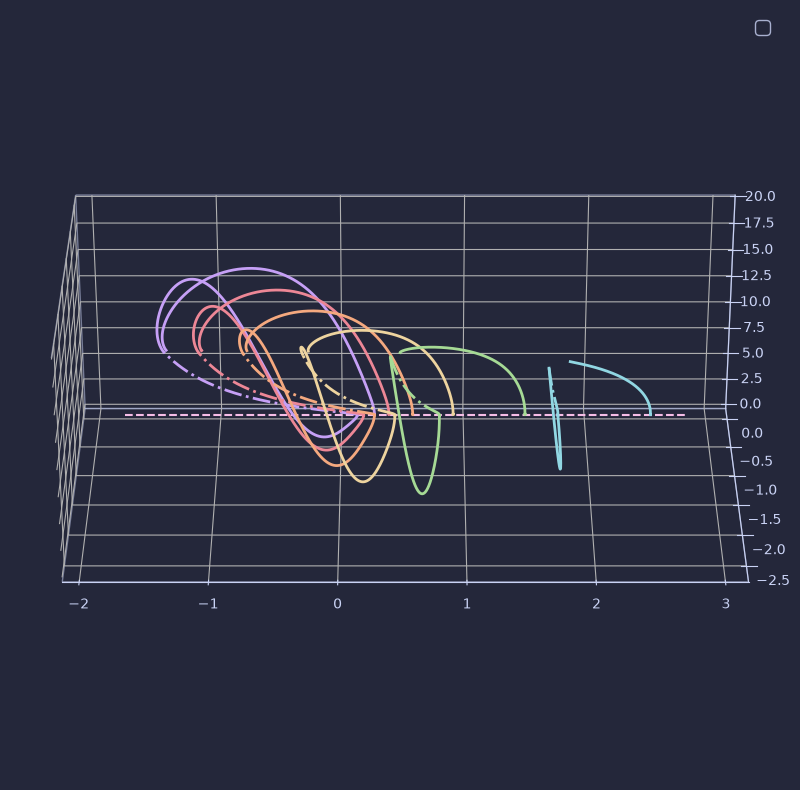

In [12]:

fig_generator = plt.figure(figsize=(10,10),facecolor='#24273a')
ax = fig_generator.add_subplot(1,1,1,projection='3d')
colors = ['#c6a0f6','#ed8796','#f5a97f','#eed49f','#a6da95','#91d7e3']

for w,i in zip([3,2.5,2,1.5,1,0.5],range(6)):

    solver = Continuation_Solver(40,w,1000,0.01,True)
    locomotion0 =  pickle.load(open('data/locomotion{}.pkl'.format(i), 'rb'))
    switch0 =  pickle.load(open('data/switch{}.pkl'.format(i), 'rb'))

    idx = [1,2,3]
    # ax.set_proj_type('ortho')
    for M in locomotion0:
        plot_generator_alt(ax,M,colors[i],2,0.01,idx)
    for M in switch0:
        plot_generator_alt(ax,M,colors[i],2,0.01,idx,linestyle='-.')

x_min,x_max = ax.get_xlim()
ax.plot([x_min,x_max],[0,0],[0,0],'--',zorder=0,color='#f5bde6')
prettify3D(ax)
ax.view_init(elev=30, azim=-90, roll=0)
ax.set_box_aspect((8,4,3))
plt.show()